In [136]:
import json
import matplotlib.pyplot as plt
import numpy as np
import time

from itertools import product
import qutip as qt

import h5py
from datetime import datetime
import sys
import os
import shutil
import importlib

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")

sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_measurements")
sys.path.append(r"E:\Research\Projects\Triangle Lattice\chiral_currents_project\Jupyter Notebooks\8Q_Triangle_Lattice_v1\current_simulations")


import current_measurements.src.src_current_measurement_simulations
importlib.reload(current_measurements.src.src_current_measurement_simulations);
from current_measurements.src.src_current_measurement_simulations import CurrentMeasurementSimulation

import current_measurements.src.src_current_measurement_simulations_particle_sector
importlib.reload(current_measurements.src.src_current_measurement_simulations_particle_sector);
from current_measurements.src.src_current_measurement_simulations_particle_sector import CurrentMeasurementSimulationParticleSector

# import current_simulations.quantum_states
# importlib.reload(current_simulations.quantum_states)
# from current_simulations.quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import quantum_states
importlib.reload(quantum_states)
from quantum_states import QuantumState, FockBasisState, FockBasisOuter, DensityMatrix

import current_simulations.current_simulation
importlib.reload(current_simulations.current_simulation)
from current_simulations.current_simulation import CurrentSimulation



In [138]:
# current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)
# test_psi0_fock = DensityMatrix(np.array(test_psi0_fock_state), test_psi0_fock_basis)
# current_simulation.psi0 = test_psi0_fock

# # current_simulation.calculate_currents_fock(test_psi0_fock, only_rungs=True, specific_pairs=[((1,2),(3,4))])
# current_simulation.calculate_current_correlations_fock(test_psi0_fock, only_rungs=True, specific_pairs=[((1,2),(3,4))])

self psi0 type: <class 'quantum_states.DensityMatrix'>


In [68]:
def convert_particle_sector_to_reduced_density_matrix(psi_4particle, 
                                                      basis_4particle, 
                                                      reduced_qubit_indices, 
                                                      num_qubits=8,
                                                      num_levels=5):
    """
    More efficient version that groups states by their traced configurations
    Handles both state vectors and density matrices as input.

    after reducing to reduced density matrix, truncate to remove states that have more than 4 particles in total
    """
    from collections import defaultdict
    
    # Check if input is a density matrix or state vector
    if hasattr(psi_4particle, 'shape') and len(psi_4particle.shape) == 2:
        # Input is a density matrix
        is_density_matrix = True
        if hasattr(psi_4particle, 'full'):
            rho_input = psi_4particle.full()  # QuTiP Qobj
        else:
            rho_input = psi_4particle  # numpy array
    else:
        # Input is a state vector
        is_density_matrix = False
        if hasattr(psi_4particle, 'full'):
            psi_input = psi_4particle.full().flatten()  # QuTiP Qobj
        else:
            psi_input = psi_4particle.flatten()  # numpy array
    

    if psi_4particle.isket:
        is_density_matrix = False
        psi_input = psi_4particle.full().flatten()

    elif psi_4particle.isoper:
        is_density_matrix = True
        rho_input = psi_4particle.full()



    traced_qubits = [i for i in range(num_qubits) if i not in reduced_qubit_indices]
    
    # Group states by (reduced_config, traced_config)
    state_groups = defaultdict(list)
    
    for i, full_state in enumerate(basis_4particle):
        reduced_part = tuple(full_state[j] for j in reduced_qubit_indices)
        traced_part = tuple(full_state[j] for j in traced_qubits)
        state_groups[(reduced_part, traced_part)].append(i)
    
    # Generate basis for reduced qubits
    reduced_basis = list(product(range(num_levels), repeat=len(reduced_qubit_indices)))
    dim_reduced = len(reduced_basis)
    rho_reduced = np.zeros((dim_reduced, dim_reduced), dtype=complex)
    
    # Build density matrix
    for alpha, reduced_alpha in enumerate(reduced_basis):
        for beta, reduced_beta in enumerate(reduced_basis):
            
            matrix_element = 0.0
            
            # Sum over all traced configurations
            all_traced_configs = set()
            for (red_part, traced_part), indices in state_groups.items():
                if red_part == reduced_alpha or red_part == reduced_beta:
                    all_traced_configs.add(traced_part)
            
            for traced_config in all_traced_configs:
                indices_alpha = state_groups.get((reduced_alpha, traced_config), [])
                indices_beta = state_groups.get((reduced_beta, traced_config), [])
                
                if is_density_matrix:
                    # For density matrix input: Tr_traced[rho] = sum over traced indices
                    for i in indices_alpha:
                        for j in indices_beta:
                            matrix_element += rho_input[i, j]
                else:
                    # For state vector input: |psi><psi| -> sum coefficients
                    coeff_alpha = sum(psi_input[i] for i in indices_alpha)
                    coeff_beta = sum(psi_input[i] for i in indices_beta)
                    matrix_element += coeff_alpha * np.conj(coeff_beta)

            rho_reduced[alpha, beta] = matrix_element

    
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]
    rho_reduced = rho_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    
    return qt.Qobj(rho_reduced, dims=[[len(basis_4Q_reduced_indices)], [len(basis_4Q_reduced_indices)]])

In [153]:
config_filename = 'current_correlations_config.json'

with open(config_filename, 'r') as f:
    config = json.load(f)

coupling_point = 'coupling_point_2'
eigenstate = 'highest'
# eigenstate = 'lowest'

dephasing = 'no_dephasing'
dephasing = 5.0
dephasing = 1.0
dephasing = 2.0
dephasing = 10.0
dephasing = 40.0

dephasing = 0.001
dephasing = 'no_dephasing'


coupling_point_config = config[coupling_point]


In [154]:


correlation_pairs = []
for i in range(1, 8):
    for j in range(i + 2, 8):
        correlation_pairs.append(((i, i+1), (j,j+1)))



In [58]:
correlation_pair_to_simulation = {}


In [59]:
### extract simulation data

simulation_config = coupling_point_config['simulation_config']

num_levels = simulation_config['num_levels']
num_qubits = simulation_config['num_qubits']
num_particles = simulation_config['num_particles']

U = simulation_config['U'] * 2  *np.pi
times = np.linspace(simulation_config['time_start'], simulation_config['time_stop'], simulation_config['time_num_points'])

J = []
J_parallel = []

if eigenstate == 'lowest':
    psi0 = -70
else:
    psi0 = simulation_config['psi0']

T1 = simulation_config['T1']
T2 = simulation_config['T2']

coupling_dict = coupling_point_config['coupling']

for i in range(num_qubits-1):
    J_key = f'J_{i+1}{i+2}'
    J_parallel_key = f'J_{i+1}{i+3}'

    if J_key in coupling_dict:
        J.append(coupling_dict[J_key])

    if J_parallel_key in coupling_dict:
        J_parallel.append(coupling_dict[J_parallel_key])

if not len(J) == num_qubits - 1:
    raise ValueError(f'coupling strengths J not properly specified in config file. Needs all pairs J_<i><i+1>. Given length: {len(J)}')

if not len(J_parallel) == num_qubits - 2:
    raise ValueError(f'coupling strengths J_parallel not properly specified in config file. Needs all pairs J_<i><i+2>. Given length: {len(J_parallel)}')

J = np.array(J)*2*np.pi
J_parallel = np.array(J_parallel)*2*np.pi



In [60]:
### load ramp dephasing state data

ramp_state_filename = '../ramp_dephasing_simulations/ramp_dephasing_states.h5'

# Load the full file structure
ramp_state_data = load_nested_dict_from_hdf5(ramp_state_filename)

print(ramp_state_data[coupling_point][eigenstate].keys())



dict_keys(['0.0001', '0.001', '0.01', '0.1', '0.5', '1.0', '10.0', '2.0', '40.0', '5.0'])


In [161]:
# create initial state from diagonalizing the particle sector Hamiltonian

simulation = CurrentMeasurementSimulationParticleSector(num_levels, num_qubits, num_particles, J, J_parallel, U, times,
                                                       [1,2], [3,4], psi0=psi0, T1=T1, T2=T2)

if not dephasing == 'no_dephasing':
    T2_sim = str(dephasing)
    if T2_sim in ramp_state_data[coupling_point][eigenstate]:
        print(f'found state for dephasing T2 = {T2_sim}')
        psi0_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate][T2_sim])
        simulation.psi0 = psi0_state
    else:
        raise KeyError

psi0_state = simulation.psi0

basis = list(product(range(num_levels), repeat=num_qubits))
basis_4Q = [state for state in basis if sum(state) == num_particles]

if psi0_state.isoper:
    print(f'purity: {(psi0_state*psi0_state).tr()}')
elif psi0_state.isket:
    print(f'pure state')
psi0_state

processing psi0, given type: <class 'int'>
pure state


Quantum object: dims=[[330], [1]], shape=(330, 1), type='ket', dtype=Dense
Qobj data =
[[ 4.28413251e-07]
 [-1.64702462e-05]
 [ 2.83527137e-04]
 [ 1.30592782e-04]
 [-4.14043717e-06]
 [-1.15601224e-05]
 [ 3.89539585e-04]
 [-3.65278082e-03]
 [ 1.17330022e-04]
 [ 2.32120780e-04]
 [-5.08294222e-03]
 [ 1.31401915e-03]
 [ 1.71079145e-06]
 [ 6.79671698e-04]
 [-9.97617599e-06]
 [ 1.45981476e-04]
 [-3.36381053e-03]
 [-1.85143117e-03]
 [ 6.29890656e-05]
 [-2.26898664e-03]
 [ 4.32829681e-02]
 [-1.49268527e-03]
 [ 3.48960320e-03]
 [-1.28538176e-02]
 [ 4.35614870e-05]
 [ 5.78975749e-04]
 [ 4.05556887e-03]
 [-9.99635262e-06]
 [-9.71491647e-03]
 [-3.94026886e-03]
 [ 3.03451813e-03]
 [-6.80653248e-04]
 [ 2.45611449e-04]
 [ 8.12780744e-04]
 [-3.24249346e-05]
 [ 1.50180240e-04]
 [-3.97605554e-03]
 [ 6.37668443e-03]
 [ 9.48488765e-05]
 [-2.07112835e-03]
 [ 4.53451719e-02]
 [-1.14688511e-02]
 [ 6.51871334e-04]
 [-8.11139561e-03]
 [ 9.98308974e-05]
 [ 9.28394953e-03]
 [-9.41606038e-02]
 [-1.90433477e-04]
 

In [62]:
def calculate_current_correlation_simulation(annihilation_operators, number_operators, initial_state, 
                                             J, J_parallel, U, measurement_detuning, readout_pair_1, readout_pair_2,
                                             capped=True):
    # Initialize timing
    start_time = time.time()
    last_time = start_time

    H_BS_reduced = 0

    q1, q2 = readout_pair_1
    q3, q4 = readout_pair_2
    qubit_indices = [q1, q2, q3, q4]

    print(f'creating Hamiltonian, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    for i in range(len(number_operators)):
        a_i = annihilation_operators[i]
        q_i = qubit_indices[i]
        for j in range(i+1, len(number_operators)):
            q_j = qubit_indices[j]
            a_j = annihilation_operators[j]
            coupling = 0
            if abs(q_i - q_j) == 1:
                coupling = J[min(q_i, q_j)]

            if abs(q_i - q_j) == 2:
                coupling = J_parallel[min(q_i, q_j)]

            H_BS_reduced += coupling*(a_i.dag()*a_j + a_j.dag()*a_i)

        H_BS_reduced += U/2 * a_i.dag()*a_i*(a_i.dag()*a_i - 1)

        H_BS_reduced += a_i.dag()*a_i*measurement_detuning[q_i]

    reduced_basis = list(product(range(num_levels), repeat=4))
    basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]

    
    print(f'Hamiltonian dims: {H_BS_reduced.dims}')

    # truncate Hamiltonian to states with 4 or fewer particles
    # H_BS_reduced = H_BS_reduced[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]

    # H_BS_reduced = qt.Qobj(H_BS_reduced, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices)))


    print(f'running simulation, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    result = qt.mesolve(H_BS_reduced, initial_state, times)

    print(f'calculating populations, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    populations = np.zeros((4, len(times)))

    for i in range(len(number_operators)):
        populations[i,:] = qt.expect(number_operators[i], result.states)

    print(f'calculating covariances, time elapsed: {time.time() - last_time:.3f}s')
    last_time = time.time()
    
    covariances = np.zeros((len(number_operators), len(number_operators), len(times)))

    number_operators_measurement = number_operators

    if capped:
        number_operators_capped = [qt.Qobj(np.clip(n.full(), 0, 1), dims=n.dims) for n in number_operators]
        # print(np.diag(number_operators_capped[0].full()))
        number_operators_measurement = number_operators_capped

    for i in range(len(number_operators_measurement)):
        for j in range(len(number_operators_measurement)):
            covariances[i,j,:] = qt.expect(number_operators_measurement[i] * number_operators_measurement[j], result.states)

    covariance_sum = 0

    covariance_sum += covariances[0,2,:] - populations[0, :] * populations[2, :]
    covariance_sum -= covariances[0,3,:] - populations[0, :] * populations[3, :]
    covariance_sum -= covariances[1,2,:] - populations[1, :] * populations[2, :]
    covariance_sum += covariances[1,3,:] - populations[1, :] * populations[3, :]

    # Calculate total function time
    total_function_time = time.time() - start_time
    print(f'done calculating current correlations, time elapsed: {time.time() - last_time:.3f}s, total function time: {total_function_time:.3f}s')

    return covariance_sum

In [63]:
### initialiaze reduced operators in 4Q subspace

a = qt.destroy(num_levels)

a_1 = qt.tensor([a, qt.qeye(num_levels), qt.qeye(num_levels), qt.qeye(num_levels)])
a_2 = qt.tensor([qt.qeye(num_levels), a, qt.qeye(num_levels), qt.qeye(num_levels)])
a_3 = qt.tensor([qt.qeye(num_levels), qt.qeye(num_levels), a, qt.qeye(num_levels)])
a_4 = qt.tensor([qt.qeye(num_levels), qt.qeye(num_levels), qt.qeye(num_levels), a])

annihilation_operators_reduced = [a_1, a_2, a_3, a_4]
number_operators_reduced = [a_i.dag()*a_i for a_i in annihilation_operators_reduced]

# truncated reduced operators to 4 or fewer particles

reduced_basis = list(product(range(num_levels), repeat=4))
basis_4Q_reduced_indices = np.where([sum(state) <= 4 for state in reduced_basis])[0]

annihilation_operators_reduced_truncated = []


for i in range(len(annihilation_operators_reduced)):
    a_i = annihilation_operators_reduced[i]
    a_i_truncated = a_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    annihilation_operators_reduced_truncated.append(qt.Qobj(a_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))

number_operators_reduced_truncated = []

for i in range(len(number_operators_reduced)):
    n_i = number_operators_reduced[i]
    n_i_truncated = n_i[basis_4Q_reduced_indices,:][:,basis_4Q_reduced_indices]
    number_operators_reduced_truncated.append(qt.Qobj(n_i_truncated, dims=(len(basis_4Q_reduced_indices), len(basis_4Q_reduced_indices))))

In [64]:
correlation_pair_to_beamsplitter_time = {}
correlation_pair_to_current_correlation = {}
correlation_pair_to_current_correlation_value = {}

In [65]:
for correlation_pair in correlation_pairs:
    # Initialize timing for this iteration
    iteration_start_time = time.time()
    last_time = iteration_start_time

    
    # config_pair_dict = coupling_point_config[str(correlation_pair)]

    readout_qubits_1, readout_qubits_2 = correlation_pair
    
    readout_pair_1 = [q - 1 for q in readout_qubits_1]
    readout_pair_2 = [q - 1 for q in readout_qubits_2]

    if not correlation_pair in correlation_pair_to_current_correlation:

        print(f'correlation pair: {correlation_pair}, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        measurement_detuning = coupling_point_config['data_config'][str(correlation_pair)]['measurement_detunings']

        # simulation beamsplitter time is not the same as the measured beamsplitter time
        average_J = 1/2*(abs(J[min(readout_pair_1)]) + abs(J[min(readout_pair_2)])) # MHz
        beamsplitter_time_simulation = np.pi/(4*average_J) # in mus

        correlation_pair_to_beamsplitter_time[correlation_pair] = beamsplitter_time_simulation

        # print(f'beamsplitter_time_simulation: {beamsplitter_time_simulation*1e3} ns')

        print(f'reducing density matrix for qubits: {readout_pair_1 + readout_pair_2}, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        rho_reduced_truncated = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  readout_pair_1 + readout_pair_2, 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)
        
        # rho_reduced = psi0_state.ptrace(readout_pair_1 + readout_pair_2)
        

        print(f'rho reduced truncated dims: {rho_reduced_truncated.dims}')

        print(f'calculating current correlation, time elapsed: {time.time() - last_time:.3f}s')
        last_time = time.time()

        current_correlation = calculate_current_correlation_simulation(annihilation_operators_reduced_truncated, number_operators_reduced_truncated, rho_reduced_truncated, 
                                             J, J_parallel, U, measurement_detuning, readout_pair_1, readout_pair_2, capped=True)

        current_correlation *= abs(J[min(readout_pair_1)]/2/np.pi) * abs(J[min(readout_pair_2)]/2/np.pi)

        correlation_pair_to_current_correlation[correlation_pair] = current_correlation

        beamsplitter_index = np.argmin(np.abs(times - beamsplitter_time_simulation))
        current_correlation_value = current_correlation[beamsplitter_index]

        correlation_pair_to_current_correlation_value[correlation_pair] = current_correlation_value

        # Calculate total iteration time
        total_iteration_time = time.time() - iteration_start_time
        print(f'done with correlation pair: {correlation_pair}, time elapsed: {time.time() - last_time:.3f}s, ')
        print(f'total iteration time: {total_iteration_time:.3f}s')
        print()

correlation pair: ((1, 2), (3, 4)), time elapsed: 0.000s
reducing density matrix for qubits: [0, 1, 2, 3], time elapsed: 0.000s


KeyboardInterrupt: 

In [ ]:
# for correlation_pair in correlation_pairs:
     

#     correlation_pair_to_current_correlation[correlation_pair] /= (2*np.pi)**2


#     correlation_pair_to_current_correlation_value[correlation_pair] /= (2*np.pi)**2

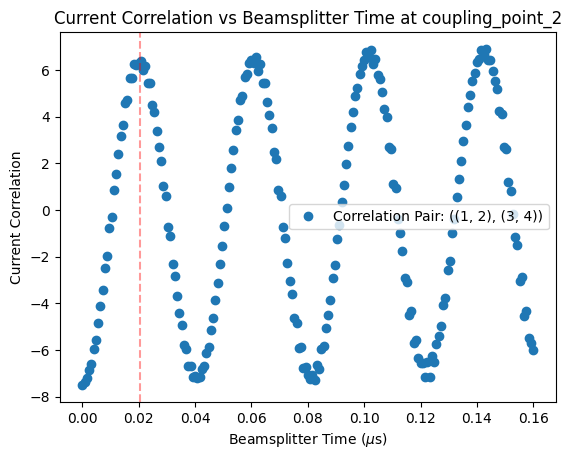

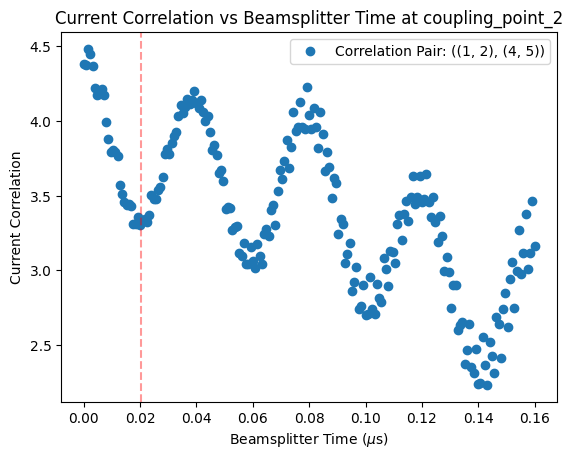

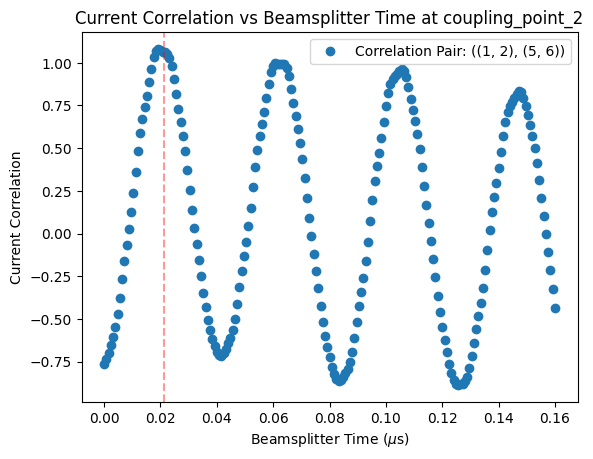

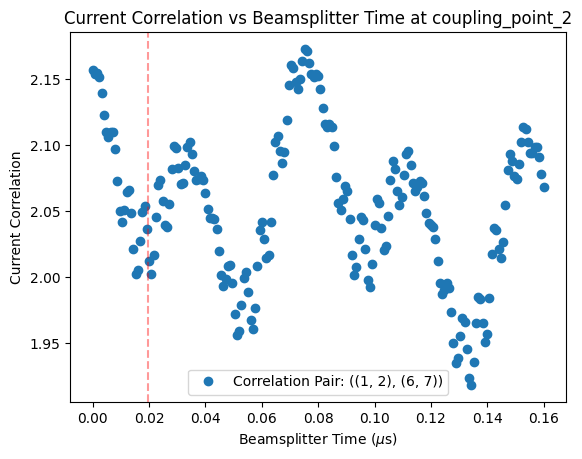

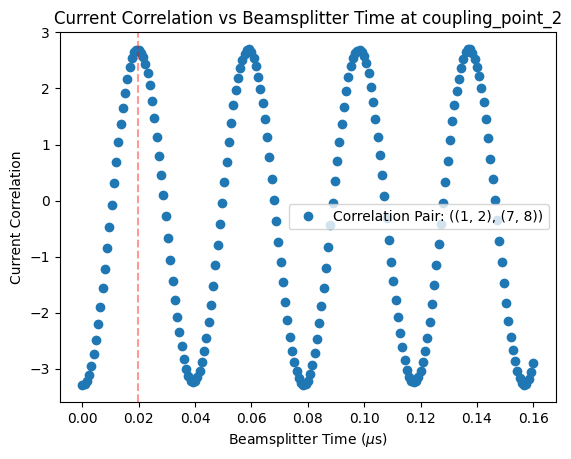

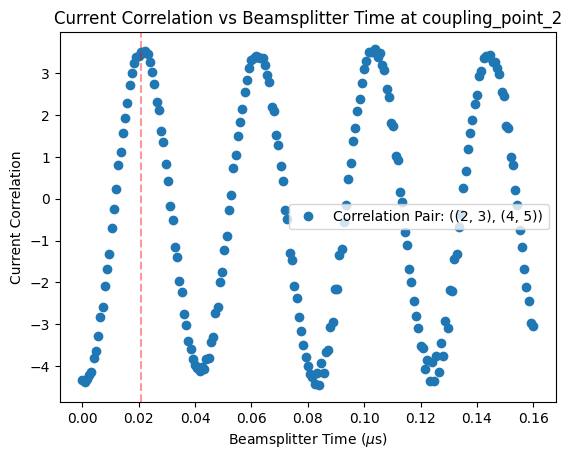

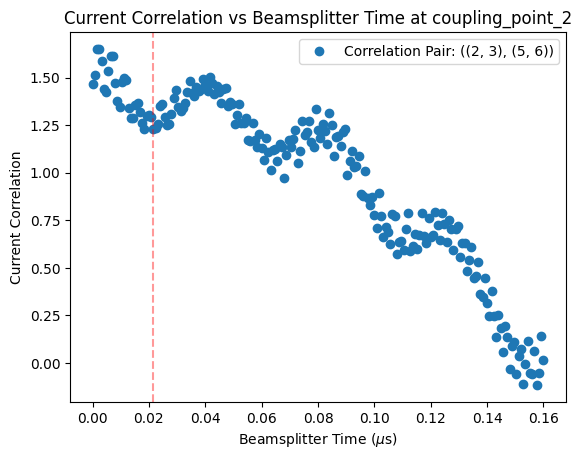

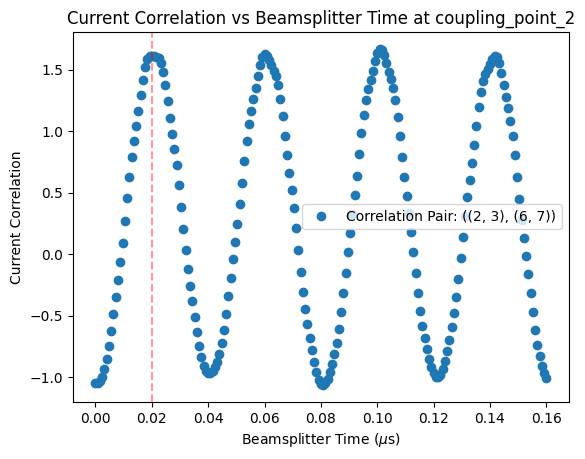

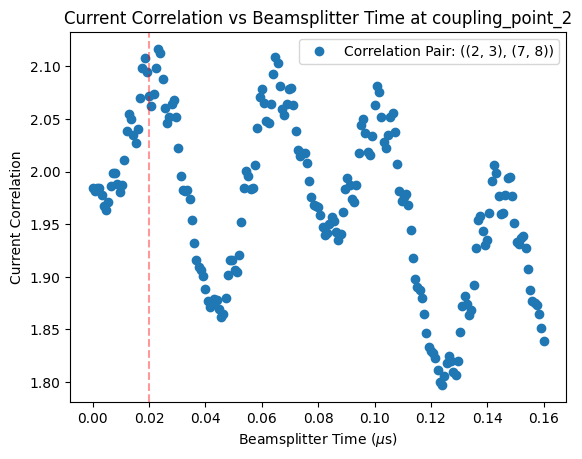

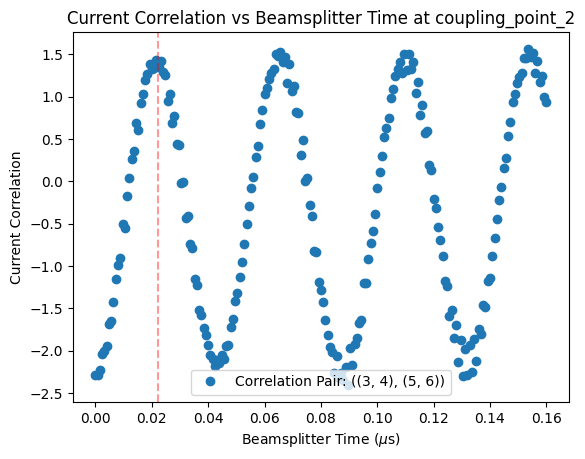

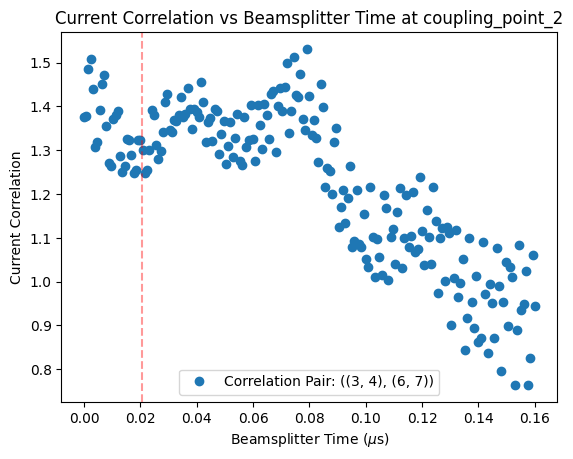

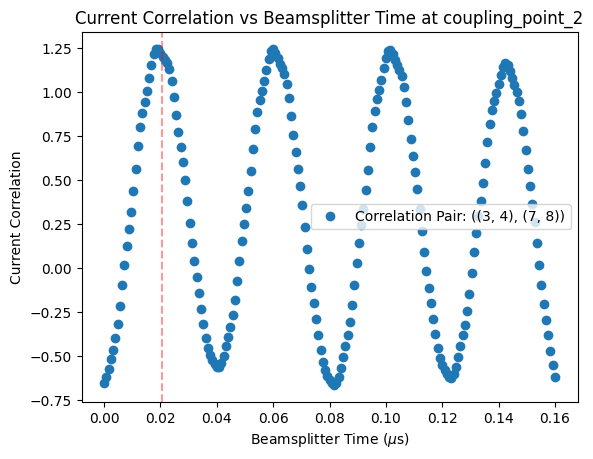

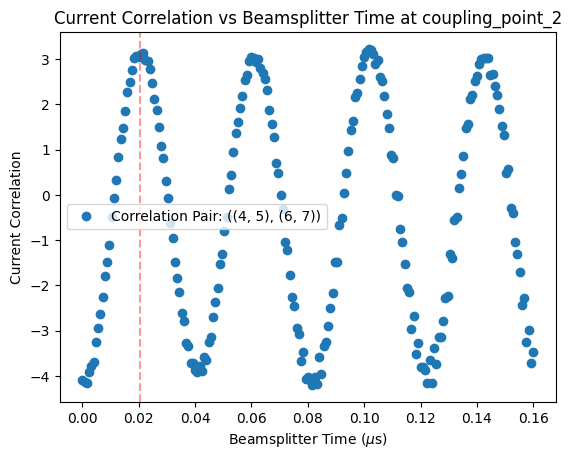

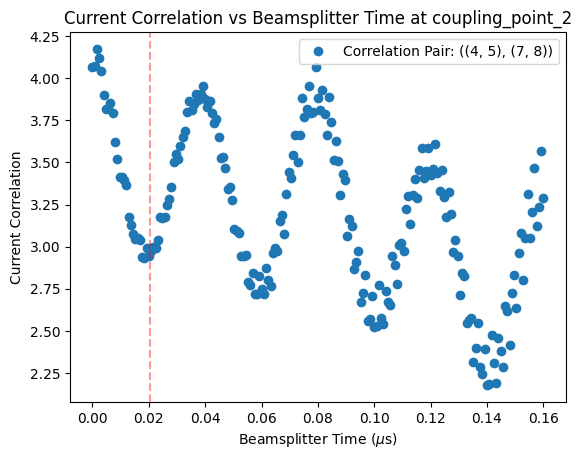

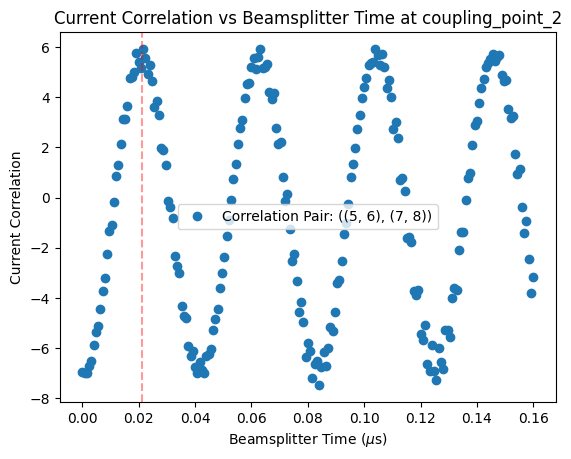

In [ ]:
for correlation_pair in correlation_pairs:

    current_correlation = correlation_pair_to_current_correlation[correlation_pair]

    beamsplitter_time_simulation = correlation_pair_to_beamsplitter_time[correlation_pair]

    plt.plot(times, current_correlation, linestyle='', marker='o', label=f'Correlation Pair: {correlation_pair}')
    plt.xlabel('Beamsplitter Time ($\mu$s)')
    plt.ylabel('Current Correlation')
    plt.title(f'Current Correlation vs Beamsplitter Time at {coupling_point}')

    # plt.ylim(-0.4, 0.4)

    plt.axvline(beamsplitter_time_simulation, color='r', alpha=0.4, linestyle='--')

    plt.legend()
    plt.show()
    

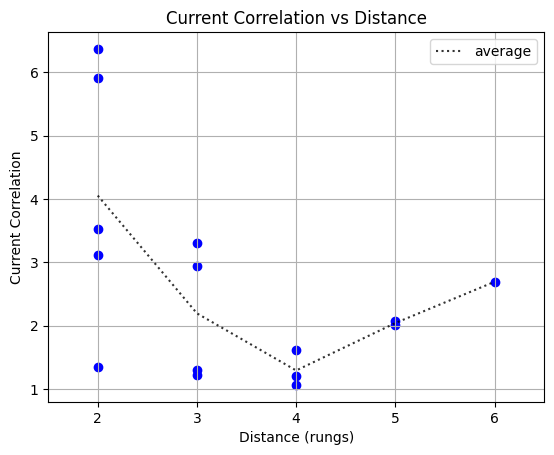

In [ ]:
current_correlation_by_distance = {}


for correlation_pair in correlation_pairs:

    current_correlation_value = correlation_pair_to_current_correlation_value[correlation_pair]

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    if not distance in current_correlation_by_distance:
        current_correlation_by_distance[distance] = []
    
    current_correlation_by_distance[distance].append(current_correlation_value)


distances = []
current_correlation_averages = []

for distance in current_correlation_by_distance:
    distances.append(distance)
    current_correlation_averages.append(np.mean(current_correlation_by_distance[distance]))

# plot
for distance in current_correlation_by_distance:
    plt.scatter([distance]*len(current_correlation_by_distance[distance]), current_correlation_by_distance[distance], color='b')

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()
plt.xlim(1.5, 6.5)

plt.title('Current Correlation vs Distance')



plt.show()

In [ ]:
current_correlation_total = sum(current_correlation_averages)
print(current_correlation_total)

12.277636384945588


In [ ]:
data_dictionary = {}

for correlation_pair in correlation_pairs:

    data_dictionary[correlation_pair] = {}


    data_dictionary[correlation_pair]['beamsplitter_time'] = correlation_pair_to_beamsplitter_time[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_BS'] = correlation_pair_to_current_correlation[correlation_pair]
    data_dictionary[correlation_pair]['current_correlation_BS_value'] = correlation_pair_to_current_correlation_value[correlation_pair]

data_dictionary['current_correlation_BS_averages'] = current_correlation_averages
data_dictionary['distances'] = distances
data_dictionary['current_correlation_BS_total'] = current_correlation_total


In [ ]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)


def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

In [ ]:
# data_filename = 'current_correlations_data.h5'

# this overwrits the whole file !!! be careful
# save_nested_dict_to_hdf5(data_filename, {coupling_point: data_dictionary})


# this line keeps only the data at the specified location
# data = load_nested_dict_from_hdf5(data_filename)
# save_nested_dict_to_hdf5(data_filename, {'data': data['data']})


In [ ]:
# data_filename = 'current_correlations_data.h5'

# keys = ('simulation', 'highest', dephasing, coupling_point)

# update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)


# 2. Exact Operator Measurement

In [155]:
current_simulation = CurrentSimulation(num_levels, num_qubits, num_particles, J_parallel, J, 0, U)
# current_simulation = CurrentSimulation(2, num_qubits, num_particles, J_parallel, J, 0, U)
# current_simulation = CurrentSimulation(2, num_qubits, num_particles, J_parallel, J, 0, 0)


In [156]:
# print(psi0_state @ psi0_state)
print((psi0_state * psi0_state).tr())

0.2504643819514806


In [163]:
# create fock state out of psi0

# psi0_state = psi0_state*psi0_state.dag()

basis_4Q_fock = [FockBasisState(state) for state in basis_4Q]

# basis_fock = [FockBasisState(state) for state in basis]

if psi0_state.isket:
    print('input state is ket')
    psi0_fock = QuantumState(psi0_state.full()[:,0], basis_4Q_fock)
elif psi0_state.isoper:
    print('input state is density matrix')
    psi0_fock_basis = []
    psi0_fock_state = []

    trace_sum = 0

    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = psi0_state.full()[i,j]
            if abs(coeff) > 1e-10:
                psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                psi0_fock_state.append(coeff)

        trace_sum += psi0_state.full()[i,i]

    psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)




input state is density matrix


# Diagnostics: State Conversion Analysis

Let's systematically diagnose the conversion from QuTiP density matrix to custom fock representation.

In [ ]:
# Diagnostic Test 1: Compare purity calculations
print("=== DIAGNOSTIC TEST 1: Purity Comparison ===")
print(f"Original QuTiP state purity: {(psi0_state * psi0_state).tr().real}")

if hasattr(psi0_fock, 'purity'):
    custom_purity = psi0_fock.purity()
    print(f"Custom fock representation purity: {custom_purity}")
    print(f"Purity difference: {abs((psi0_state * psi0_state).tr().real - custom_purity)}")
else:
    # Calculate purity manually for custom representation
    if hasattr(psi0_fock, 'trace'):
        trace_val = psi0_fock.trace()
        print(f"Custom fock representation trace: {trace_val}")

print(f"Is input a density matrix? {psi0_state.isoper}")
print(f"Is input a ket? {psi0_state.isket}")
print(f"Input state shape: {psi0_state.shape}")
print(f"Input state dims: {psi0_state.dims}")
print()

=== DIAGNOSTIC TEST 1: Purity Comparison ===
Original QuTiP state purity: 0.2504643819514806
Custom fock representation purity: 0.25046438195148174
Purity difference: 1.1657341758564144e-15
Is input a density matrix? True
Is input a ket? False
Input state shape: (330, 330)
Input state dims: [[330], [330]]



In [ ]:
# Diagnostic Test 2: Analyze density matrix structure
print("=== DIAGNOSTIC TEST 2: Density Matrix Structure ===")

if psi0_state.isoper:
    rho_full = psi0_state.full()
    
    # Check diagonal vs off-diagonal elements
    diagonal_sum = np.sum(np.abs(np.diag(rho_full)))
    off_diagonal_sum = np.sum(np.abs(rho_full)) - diagonal_sum
    
    print(f"Diagonal element sum: {diagonal_sum:.6f}")
    print(f"Off-diagonal element sum: {off_diagonal_sum:.6f}")
    print(f"Off-diagonal/Total ratio: {off_diagonal_sum/(diagonal_sum + off_diagonal_sum):.6f}")
    
    # Count significant elements
    threshold = 1e-10
    significant_diagonal = np.sum(np.abs(np.diag(rho_full)) > threshold)
    significant_off_diagonal = np.sum(np.abs(rho_full - np.diag(np.diag(rho_full))) > threshold)
    
    print(f"Significant diagonal elements (>{threshold}): {significant_diagonal}")
    print(f"Significant off-diagonal elements (>{threshold}): {significant_off_diagonal}")
    
    # Check if state is effectively mixed
    eigenvals = np.linalg.eigvals(rho_full)
    eigenvals = eigenvals[eigenvals > 1e-12]  # Filter numerical zeros
    von_neumann_entropy = -np.sum(eigenvals * np.log2(eigenvals + 1e-16))
    
    print(f"Von Neumann entropy: {von_neumann_entropy:.6f}")
    print(f"Number of significant eigenvalues: {len(eigenvals)}")
    print(f"Largest eigenvalue: {np.max(eigenvals):.6f}")
    print()

=== DIAGNOSTIC TEST 2: Density Matrix Structure ===
Diagonal element sum: 1.000000
Off-diagonal element sum: 34.364129
Off-diagonal/Total ratio: 0.971723
Significant diagonal elements (>1e-10): 330
Significant off-diagonal elements (>1e-10): 108550
Von Neumann entropy: 3.679923+0.000000j
Number of significant eigenvalues: 328
Largest eigenvalue: 0.487255+0.000000j



In [ ]:
# Diagnostic Test 3: Custom fock conversion analysis
print("=== DIAGNOSTIC TEST 3: Custom Fock Conversion ===")

if psi0_state.isoper:
    # Detailed analysis of the conversion process
    rho_full = psi0_state.full()
    
    # Count elements by type in the conversion
    diagonal_count = 0
    off_diagonal_count = 0
    threshold = 1e-10
    
    diagonal_coeffs = []
    off_diagonal_coeffs = []
    
    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = rho_full[i,j]
            if abs(coeff) > threshold:
                if i == j:
                    diagonal_count += 1
                    diagonal_coeffs.append(abs(coeff))
                else:
                    off_diagonal_count += 1
                    off_diagonal_coeffs.append(abs(coeff))
    
    print(f"Elements included in custom representation:")
    print(f"  Diagonal: {diagonal_count}")
    print(f"  Off-diagonal: {off_diagonal_count}")
    print(f"  Total: {diagonal_count + off_diagonal_count}")
    
    if diagonal_coeffs:
        print(f"  Diagonal coefficient range: {min(diagonal_coeffs):.2e} to {max(diagonal_coeffs):.2e}")
    if off_diagonal_coeffs:
        print(f"  Off-diagonal coefficient range: {min(off_diagonal_coeffs):.2e} to {max(off_diagonal_coeffs):.2e}")
    
    # Check trace preservation
    original_trace = np.trace(rho_full)
    
    # Manually calculate trace from conversion
    converted_trace = 0
    for i in range(len(basis_4Q)):
        coeff = rho_full[i,i]
        if abs(coeff) > threshold:
            converted_trace += coeff
    
    print(f"Original trace: {original_trace:.6f}")
    print(f"Converted trace: {converted_trace:.6f}")
    print(f"Trace preservation error: {abs(original_trace - converted_trace):.2e}")
    print()

=== DIAGNOSTIC TEST 3: Custom Fock Conversion ===
Elements included in custom representation:
  Diagonal: 330
  Off-diagonal: 108550
  Total: 108880
  Diagonal coefficient range: 1.20e-09 to 4.75e-02
  Off-diagonal coefficient range: 1.03e-10 to 3.37e-02
Original trace: 1.000000-0.000000j
Converted trace: 1.000000-0.000000j
Trace preservation error: 2.22e-16



In [123]:
# Diagnostic Test 4: Test with artificially mixed states
print("=== DIAGNOSTIC TEST 4: Controlled Mixing Test ===")

# Create a series of artificially mixed states with known purities
def create_mixed_state(pure_state, mixing_ratio):
    """Create a mixed state: (1-mixing_ratio) * pure_state + mixing_ratio * maximally_mixed"""
    dim = pure_state.shape[0]
    identity = qt.qeye(dim) / dim
    mixed = (1 - mixing_ratio) * pure_state + mixing_ratio * identity
    return mixed

# Get the pure state (no dephasing)
pure_eigenstate_index = simulation_config['psi0'] 
eigenstates = simulation.get_eigenstates(simulation.num_particles)
pure_state = eigenstates[pure_eigenstate_index]
pure_dm = pure_state * pure_state.dag()

# Test different mixing ratios
mixing_ratios = [0.0, 0.1, 0.5, 0.9, 1.0]
mixing_ratios = [0.0, 0.5, 0.9]
print("Testing artificial mixing ratios...")

for ratio in mixing_ratios:
    test_state = create_mixed_state(pure_dm, ratio)
    purity_qutip = (test_state * test_state).tr().real
    
    # Convert to custom representation  
    test_psi0_fock_basis = []
    test_psi0_fock_state = []
    rho_test = test_state.full()
    
    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = rho_test[i,j]
            if abs(coeff) > 1e-10:
                test_psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                test_psi0_fock_state.append(coeff)
    
    test_psi0_fock = DensityMatrix(np.array(test_psi0_fock_state), test_psi0_fock_basis)
    
    # Calculate current correlation for this test state
    current_simulation.psi0 = test_psi0_fock
    specific_pairs = [((1,2),(3,4))]
    test_correlations = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    
    # Get a representative correlation value
    test_corr_val = test_correlations[((1,2), (3,4))] if ((1,2), (3,4)) in test_correlations else list(test_correlations.values())[0]
    
    print(f"  Mixing ratio: {ratio:.1f}, Purity: {purity_qutip:.4f}, Correlation: {test_corr_val:.6f}")

print()

=== DIAGNOSTIC TEST 4: Controlled Mixing Test ===
Testing artificial mixing ratios...


KeyboardInterrupt: 

In [144]:
# Diagnostic Test 5: Compare different T2 states directly
print("=== DIAGNOSTIC TEST 5: Direct T2 Comparison ===")

# Load multiple T2 values and compare their properties
available_T2_values = []
for key in ramp_state_data[coupling_point][eigenstate].keys():
    try:
        t2_val = float(key)
        available_T2_values.append(t2_val)
    except:
        continue

available_T2_values.sort()
print(f"Available T2 values: {available_T2_values}")


# Compare the first few T2 values
test_T2_values = available_T2_values[:5] if len(available_T2_values) >= 5 else available_T2_values

chosen_T2_values = [0.0001, 0.001, 0.01, 0.1]
print(f'chosen T2 values for comparison: {chosen_T2_values}')
test_T2_values = chosen_T2_values

print("\nDirect comparison of different T2 states:")
print("T2\t\tPurity\t\tTrace\t\tMax_diag\tCorrelation")
print("-" * 70)

correlations_by_T2 = {}

for t2_val in test_T2_values:
    # Load state for this T2
    test_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate][str(t2_val)])
    
    # Basic properties
    purity = (test_state * test_state).tr().real
    trace = test_state.tr().real
    max_diag = np.max(np.abs(np.diag(test_state.full())))
    
    # Convert to custom representation
    test_psi0_fock_basis = []
    test_psi0_fock_state = []
    rho_test = test_state.full()
    
    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = rho_test[i,j]
            if abs(coeff) > 1e-10:
                test_psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                test_psi0_fock_state.append(coeff)
    
    test_psi0_fock = DensityMatrix(np.array(test_psi0_fock_state), test_psi0_fock_basis)
    
    # Calculate current correlation
    current_simulation.psi0 = test_psi0_fock

    specific_pairs = [((1,2),(3,4))]
    test_correlations = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    representative_corr = test_correlations[((1,2), (3,4))] if ((1,2), (3,4)) in test_correlations else list(test_correlations.values())[0]
    
    correlations_by_T2[t2_val] = representative_corr
    
    print(f"{t2_val}\t\t{purity:.4f}\t\t{trace:.4f}\t\t{max_diag:.4f}\t\t{representative_corr:.6f}")

print(f"\nCorrelation range: {min(correlations_by_T2.values()):.6f} to {max(correlations_by_T2.values()):.6f}")
print(f"Correlation variation: {max(correlations_by_T2.values()) - min(correlations_by_T2.values()):.6f}")
print()

=== DIAGNOSTIC TEST 5: Direct T2 Comparison ===
Available T2 values: [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 40.0]
chosen T2 values for comparison: [0.0001, 0.001, 0.01, 0.1]

Direct comparison of different T2 states:
T2		Purity		Trace		Max_diag	Correlation
----------------------------------------------------------------------
self psi0 type: <class 'quantum_states.DensityMatrix'>
0.0001		0.0094		1.0000		0.0118		0.091709
self psi0 type: <class 'quantum_states.DensityMatrix'>
0.001		0.2505		1.0000		0.0475		7.890800
self psi0 type: <class 'quantum_states.DensityMatrix'>
0.01		0.8616		1.0000		0.0714		13.572480
self psi0 type: <class 'quantum_states.DensityMatrix'>
0.1		0.9851		1.0000		0.0747		14.337927

Correlation range: 0.091709 to 14.337927
Correlation variation: 14.246218



In [145]:
# Diagnostic Test 6: Test different thresholds and conversion approaches
print("=== DIAGNOSTIC TEST 6: Threshold and Conversion Testing ===")

# Test with different thresholds
thresholds = [1e-16, 1e-12, 1e-10, 1e-8, 1e-6]

print("Testing different element thresholds...")
print("Threshold\t\tElements\t\tCorrelation")
print("-" * 50)

for threshold in thresholds:
    # Convert with this threshold
    test_psi0_fock_basis = []
    test_psi0_fock_state = []
    rho_full = psi0_state.full()
    
    for i in range(len(basis_4Q)):
        for j in range(len(basis_4Q)):
            coeff = rho_full[i,j]
            if abs(coeff) > threshold:
                test_psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[j]))
                test_psi0_fock_state.append(coeff)
    
    test_psi0_fock = DensityMatrix(np.array(test_psi0_fock_state), test_psi0_fock_basis)
    
    # Calculate correlation
    current_simulation.psi0 = test_psi0_fock
    test_correlations = current_simulation.get_current_correlations(only_rungs=True)
    representative_corr = test_correlations[((1,2), (3,4))] if ((1,2), (3,4)) in test_correlations else list(test_correlations.values())[0]
    
    print(f"{threshold:.0e}\t\t\t{len(test_psi0_fock_state)}\t\t\t{representative_corr:.6f}")

print()

=== DIAGNOSTIC TEST 6: Threshold and Conversion Testing ===
Testing different element thresholds...
Threshold		Elements		Correlation
--------------------------------------------------
self psi0 type: <class 'quantum_states.DensityMatrix'>
1e-16			108900			7.890800
self psi0 type: <class 'quantum_states.DensityMatrix'>
1e-12			108900			7.890800
self psi0 type: <class 'quantum_states.DensityMatrix'>
1e-10			108880			7.890800
self psi0 type: <class 'quantum_states.DensityMatrix'>
1e-08			107722			7.890800


ValueError: Density matrix must have trace 1.

In [146]:
# Diagnostic Test 7: Validate custom DensityMatrix operations
print("=== DIAGNOSTIC TEST 7: Custom DensityMatrix Validation ===")

# Test basic operations of the custom DensityMatrix class
print("Testing custom DensityMatrix class operations...")

# Create a simple test case: pure state |11000000⟩⟨11000000|
test_state_vec = [1, 1, 0, 0, 0, 0, 0, 0]  # 2 particles in first 2 sites
test_fock_state = FockBasisState(test_state_vec)
test_pure_dm = DensityMatrix([1.0], [FockBasisOuter(test_state_vec, test_state_vec)])

print(f"Pure state trace: {test_pure_dm.trace()}")
if hasattr(test_pure_dm, 'purity'):
    print(f"Pure state purity: {test_pure_dm.purity()}")

# Create a mixed state: 0.5|11000000⟩⟨11000000| + 0.5|02000000⟩⟨02000000|
test_state_vec2 = [0, 2, 0, 0, 0, 0, 0, 0]  # 2 particles in second site
test_mixed_dm = DensityMatrix([0.5, 0.5], 
                              [FockBasisOuter(test_state_vec, test_state_vec),
                               FockBasisOuter(test_state_vec2, test_state_vec2)])

print(f"Mixed state trace: {test_mixed_dm.trace()}")
if hasattr(test_mixed_dm, 'purity'):
    print(f"Mixed state purity: {test_mixed_dm.purity()}")

# Test operator application
print("\nTesting operator applications on simple states...")

# Apply a†_1 a_2 to the pure state (should give 0)
test_op_result = test_pure_dm.apply_raising_operator(0, num_levels).apply_lowering_operator(1)
expectation_val = test_pure_dm.inner_product(test_op_result) if hasattr(test_pure_dm, 'inner_product') else "N/A"
print(f"⟨a†_1 a_2⟩ for |11000000⟩: {expectation_val}")

# Apply a†_2 a_1 to the pure state (should give 1)  
test_op_result2 = test_pure_dm.apply_raising_operator(1, num_levels).apply_lowering_operator(0)
expectation_val2 = test_pure_dm.inner_product(test_op_result2) if hasattr(test_pure_dm, 'inner_product') else "N/A"
print(f"⟨a†_2 a_1⟩ for |11000000⟩: {expectation_val2}")

print("\nComparing with your actual dephased state...")
print(f"Actual state has {len(psi0_fock.state)} elements in custom representation")
print(f"Basis size: {len(psi0_fock.basis)}")

# Check if the issue is in specific operations
if len(psi0_fock.state) > 100:  # Only for non-trivial states
    # Sample a few operator applications
    sample_ops = [
        (0, 1),  # a†_1 a_2  
        (1, 0),  # a†_2 a_1
        (0, 2),  # a†_1 a_3
        (2, 0),  # a†_3 a_1
    ]
    
    print("Sample operator expectations on dephased state:")
    for i, j in sample_ops:
        try:
            op_result = psi0_fock.apply_raising_operator(i, num_levels).apply_lowering_operator(j)
            expectation = psi0_fock.inner_product(op_result) if hasattr(psi0_fock, 'inner_product') else "N/A"
            print(f"  ⟨a†_{i+1} a_{j+1}⟩: {expectation}")
        except Exception as e:
            print(f"  Error computing ⟨a†_{i+1} a_{j+1}⟩: {e}")

print()

=== DIAGNOSTIC TEST 7: Custom DensityMatrix Validation ===
Testing custom DensityMatrix class operations...
Pure state trace: 1.0
Pure state purity: 1.0
Mixed state trace: 1.0
Mixed state purity: 0.5

Testing operator applications on simple states...
⟨a†_1 a_2⟩ for |11000000⟩: N/A
⟨a†_2 a_1⟩ for |11000000⟩: N/A

Comparing with your actual dephased state...
Actual state has 108880 elements in custom representation
Basis size: 108880
Sample operator expectations on dephased state:
  ⟨a†_1 a_2⟩: N/A
  ⟨a†_2 a_1⟩: N/A
  ⟨a†_1 a_3⟩: N/A
  ⟨a†_3 a_1⟩: N/A



# Conversion Validation Tests

Testing the conversion from QuTiP states to custom representations and comparing no-dephasing vs high T2.

In [147]:
# Conversion Test 1: Validate QuTiP to Custom conversion
print("=== CONVERSION TEST 1: QuTiP to Custom Conversion ===")

def convert_qutip_to_custom_detailed(qutip_state, basis_list, threshold=1e-10):
    """
    Detailed conversion function with extensive logging
    """
    print(f"Input state type: {type(qutip_state)}")
    print(f"Input state shape: {qutip_state.shape}")
    print(f"Input state is_ket: {qutip_state.isket}")
    print(f"Input state is_oper: {qutip_state.isoper}")
    print(f"Basis size: {len(basis_list)}")
    
    if qutip_state.isket:
        # State vector case
        print("Converting state vector...")
        psi_input = qutip_state.full().flatten()
        custom_basis = [FockBasisState(state) for state in basis_list]
        custom_coeffs = []
        
        for i, coeff in enumerate(psi_input):
            if abs(coeff) > threshold:
                custom_coeffs.append(coeff)
            else:
                custom_coeffs.append(0.0)  # Keep structure for now
                
        # Remove zero coefficients and corresponding basis
        non_zero_indices = [i for i, c in enumerate(custom_coeffs) if abs(c) > threshold]
        final_coeffs = [custom_coeffs[i] for i in non_zero_indices]
        final_basis = [custom_basis[i] for i in non_zero_indices]
        
        print(f"Non-zero coefficients: {len(final_coeffs)} out of {len(custom_coeffs)}")
        print(f"Coefficient range: {min([abs(c) for c in final_coeffs]):.2e} to {max([abs(c) for c in final_coeffs]):.2e}")
        
        return QuantumState(final_coeffs, final_basis)
        
    elif qutip_state.isoper:
        # Density matrix case
        print("Converting density matrix...")
        rho_input = qutip_state.full()
        custom_basis = []
        custom_coeffs = []
        
        total_elements = 0
        kept_elements = 0
        diagonal_elements = 0
        off_diagonal_elements = 0
        
        for i in range(len(basis_list)):
            for j in range(len(basis_list)):
                total_elements += 1
                coeff = rho_input[i, j]
                
                if abs(coeff) > threshold:
                    kept_elements += 1
                    custom_basis.append(FockBasisOuter(basis_list[i], basis_list[j]))
                    custom_coeffs.append(coeff)
                    
                    if i == j:
                        diagonal_elements += 1
                    else:
                        off_diagonal_elements += 1
                        
        print(f"Total matrix elements: {total_elements}")
        print(f"Kept elements (>{threshold}): {kept_elements}")
        print(f"  Diagonal: {diagonal_elements}")
        print(f"  Off-diagonal: {off_diagonal_elements}")
        print(f"Sparsity: {1 - kept_elements/total_elements:.4f}")
        
        if custom_coeffs:
            print(f"Coefficient range: {min([abs(c) for c in custom_coeffs]):.2e} to {max([abs(c) for c in custom_coeffs]):.2e}")
        
        return DensityMatrix(custom_coeffs, custom_basis)
    
    else:
        raise ValueError("Input must be either ket or operator")

# Test the conversion with a known state
print("Testing with current psi0_state...")
print(f"psi0_state type: {type(psi0_state)}")
detailed_conversion = convert_qutip_to_custom_detailed(psi0_state, basis_4Q)
print(f"Conversion successful: {type(detailed_conversion)}")
print()

=== CONVERSION TEST 1: QuTiP to Custom Conversion ===
Testing with current psi0_state...
psi0_state type: <class 'qutip.core.qobj.Qobj'>
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108880
  Diagonal: 330
  Off-diagonal: 108550
Sparsity: 0.0002
Coefficient range: 1.03e-10 to 4.75e-02
Conversion successful: <class 'quantum_states.DensityMatrix'>



In [148]:
# Conversion Test 2: Compare no-dephasing pure state vs T2=40 mixed state
print("=== CONVERSION TEST 2: No-dephasing vs High T2 Comparison ===")

# Get the pure eigenstate (no dephasing)
print("Creating no-dephasing simulation...")
simulation_no_dephasing = CurrentMeasurementSimulationParticleSector(
    num_levels, num_qubits, num_particles, J, J_parallel, U, times,
    [1,2], [3,4], psi0=psi0, T1=T1, T2=T2
)

# Get the pure state as a density matrix for comparison
pure_eigenstate = simulation_no_dephasing.psi0  # This should be a ket
pure_as_dm = pure_eigenstate * pure_eigenstate.dag()

print(f"Pure state type: {type(pure_eigenstate)}")
print(f"Pure as DM type: {type(pure_as_dm)}")
print(f"Pure as DM purity: {(pure_as_dm * pure_as_dm).tr().real:.6f}")
print(f"Pure as DM trace: {pure_as_dm.tr().real:.6f}")

# Load T2=40 state for comparison
if '40.0' in ramp_state_data[coupling_point][eigenstate]:
    t2_40_state = qt.Qobj(ramp_state_data[coupling_point][eigenstate]['40.0'])
    print(f"T2=40 state purity: {(t2_40_state * t2_40_state).tr().real:.6f}")
    print(f"T2=40 state trace: {t2_40_state.tr().real:.6f}")
    
    # Compare matrix elements
    pure_matrix = pure_as_dm.full()
    t2_40_matrix = t2_40_state.full()
    
    print(f"Matrix element difference (Frobenius norm): {np.linalg.norm(pure_matrix - t2_40_matrix):.6f}")
    print(f"Max difference in matrix elements: {np.max(np.abs(pure_matrix - t2_40_matrix)):.6f}")
    
    # Check how many significant diagonal elements each has
    pure_diag = np.diag(pure_matrix)
    t2_40_diag = np.diag(t2_40_matrix)
    
    threshold = 1e-6
    pure_significant = np.sum(np.abs(pure_diag) > threshold)
    t2_40_significant = np.sum(np.abs(t2_40_diag) > threshold)
    
    print(f"Significant diagonal elements (>{threshold}): Pure={pure_significant}, T2=40={t2_40_significant}")
    
else:
    print("T2=40.0 state not found in data")
    t2_40_state = None

print()

=== CONVERSION TEST 2: No-dephasing vs High T2 Comparison ===
Creating no-dephasing simulation...
processing psi0, given type: <class 'int'>
Pure state type: <class 'qutip.core.qobj.Qobj'>
Pure as DM type: <class 'qutip.core.qobj.Qobj'>
Pure as DM purity: 1.000000
Pure as DM trace: 1.000000
T2=40 state purity: 0.999981
T2=40 state trace: 1.000000
Matrix element difference (Frobenius norm): 0.307512
Max difference in matrix elements: 0.016695
Significant diagonal elements (>1e-06): Pure=231, T2=40=252



In [150]:
# Conversion Test 3: Side-by-side current correlation comparison
print("=== CONVERSION TEST 3: Current Correlation Comparison ===")

# Convert both states to custom representation
print("Converting pure eigenstate to custom representation...")
pure_as_dm_custom = convert_qutip_to_custom_detailed(pure_as_dm, basis_4Q, threshold=1e-10)

if t2_40_state is not None:
    print("\nConverting T2=40 state to custom representation...")
    t2_40_custom = convert_qutip_to_custom_detailed(t2_40_state, basis_4Q, threshold=1e-10)
    
    # Calculate current correlations for both
    print("\n--- Current correlation calculations ---")
    

    specific_pairs = [((1,2),(3,4))]

    # Pure state correlations
    current_simulation.psi0 = pure_as_dm_custom
    pure_correlations = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    
    # T2=40 state correlations
    current_simulation.psi0 = t2_40_custom
    t2_40_correlations = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    
    print("\nCorrelation comparison:")
    print("Pair\t\t\tPure\t\tT2=40\t\tDifference")
    print("-" * 60)
    
    max_diff = 0
    for pair in pure_correlations:
        if pair in t2_40_correlations:
            pure_val = pure_correlations[pair]
            t2_40_val = t2_40_correlations[pair]
            diff = abs(pure_val - t2_40_val)
            max_diff = max(max_diff, diff)
            
            print(f"{pair}\t{pure_val:.6f}\t{t2_40_val:.6f}\t{diff:.6f}")
    
    print(f"\nMaximum difference: {max_diff:.6f}")
    
    if max_diff < 1e-6:
        print("✓ States produce nearly identical correlations - conversion appears correct")
    else:
        print("⚠ States produce different correlations - potential issue in conversion or state preparation")
        
else:
    print("Cannot compare - T2=40 state not available")

print()

=== CONVERSION TEST 3: Current Correlation Comparison ===
Converting pure eigenstate to custom representation...
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108608
  Diagonal: 322
  Off-diagonal: 108286
Sparsity: 0.0027
Coefficient range: 1.02e-10 to 6.02e-02

Converting T2=40 state to custom representation...
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108891
  Diagonal: 329
  Off-diagonal: 108562
Sparsity: 0.0001
Coefficient range: 1.19e-10 to 7.51e-02

--- Current correlation calculations ---
self psi0 type: <class 'quantum_states.DensityMatrix'>
self psi0 type: <class 'quantum_states.DensityMatrix'>

Correlation comp

In [151]:
# Conversion Test 4: Deep dive into conversion consistency
print("=== CONVERSION TEST 4: Conversion Consistency Check ===")

def check_conversion_consistency(qutip_state, basis_list, description=""):
    """Check if conversion preserves key quantum properties"""
    print(f"\nChecking {description}...")
    
    # Convert using your original method
    original_conversion = None
    if qutip_state.isket:
        psi_coeffs = qutip_state.full()[:, 0]
        basis_fock = [FockBasisState(state) for state in basis_list]
        original_conversion = QuantumState(psi_coeffs, basis_fock)
    elif qutip_state.isoper:
        rho_full = qutip_state.full()
        fock_basis = []
        fock_state = []
        for i in range(len(basis_list)):
            for j in range(len(basis_list)):
                coeff = rho_full[i, j]
                if abs(coeff) > 1e-10:
                    fock_basis.append(FockBasisOuter(basis_list[i], basis_list[j]))
                    fock_state.append(coeff)
        original_conversion = DensityMatrix(np.array(fock_state), fock_basis)
    
    # Convert using detailed method
    detailed_conversion = convert_qutip_to_custom_detailed(qutip_state, basis_list, threshold=1e-10)
    
    print(f"Original method elements: {len(original_conversion.state) if original_conversion else 'N/A'}")
    print(f"Detailed method elements: {len(detailed_conversion.state)}")
    
    if original_conversion is not None:
        # Compare traces
        orig_trace = original_conversion.trace() if hasattr(original_conversion, 'trace') else "N/A"
        detail_trace = detailed_conversion.trace() if hasattr(detailed_conversion, 'trace') else "N/A" 
        print(f"Trace - Original: {orig_trace}, Detailed: {detail_trace}")
        
        # Compare purities (for density matrices)
        if hasattr(original_conversion, 'purity') and hasattr(detailed_conversion, 'purity'):
            orig_purity = original_conversion.purity()
            detail_purity = detailed_conversion.purity()
            print(f"Purity - Original: {orig_purity:.6f}, Detailed: {detail_purity:.6f}")
            print(f"Purity difference: {abs(orig_purity - detail_purity):.2e}")
    
    # Check QuTiP properties
    qutip_trace = qutip_state.tr().real
    qutip_purity = (qutip_state * qutip_state).tr().real if qutip_state.isoper else 1.0
    
    print(f"QuTiP - Trace: {qutip_trace:.6f}, Purity: {qutip_purity:.6f}")
    
    return original_conversion, detailed_conversion

# Test both states
if t2_40_state is not None:
    orig_pure, detail_pure = check_conversion_consistency(pure_as_dm, basis_4Q, "pure eigenstate as DM")
    orig_t2, detail_t2 = check_conversion_consistency(t2_40_state, basis_4Q, "T2=40 state")
    
    # Final comparison
    print(f"\n=== FINAL CONSISTENCY CHECK ===")
    if orig_pure and detail_pure and orig_t2 and detail_t2:
        print("All conversions completed successfully")
        
        # Check if the conversion method makes a difference in correlations
        current_simulation.psi0 = orig_pure
        orig_pure_corr = current_simulation.get_current_correlations(only_rungs=True)
        
        current_simulation.psi0 = detail_pure  
        detail_pure_corr = current_simulation.get_current_correlations(only_rungs=True)
        
        # Compare first correlation
        test_pair = list(orig_pure_corr.keys())[0]
        diff = abs(orig_pure_corr[test_pair] - detail_pure_corr[test_pair])
        print(f"Pure state correlation difference between methods: {diff:.2e}")
        
        if diff < 1e-10:
            print("✓ Conversion methods give identical results")
        else:
            print("⚠ Conversion methods give different results!")
    
print()

=== CONVERSION TEST 4: Conversion Consistency Check ===

Checking pure eigenstate as DM...
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108608
  Diagonal: 322
  Off-diagonal: 108286
Sparsity: 0.0027
Coefficient range: 1.02e-10 to 6.02e-02
Original method elements: 108608
Detailed method elements: 108608
Trace - Original: (0.9999999997086108+0j), Detailed: (0.9999999997086108+0j)
Purity - Original: 1.000000, Detailed: 1.000000
Purity difference: 0.00e+00
QuTiP - Trace: 1.000000, Purity: 1.000000

Checking T2=40 state...
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108891
  Diagonal: 329
  Off-diagonal: 108562
Sparsity: 0.00

In [152]:
# Final Test: Create controlled no-dephasing simulation that should match T2=40
print("=== FINAL TEST: Controlled No-dephasing vs T2=40 ===")

# Method 1: Create pure state simulation from scratch
print("Method 1: Fresh pure state simulation...")
fresh_simulation = CurrentMeasurementSimulationParticleSector(
    num_levels, num_qubits, num_particles, J, J_parallel, U, times,
    [1,2], [3,4], psi0=psi0, T1=T1, T2=T2  # This should give pure eigenstate
)

# Convert to custom representation as state vector, then to density matrix
fresh_pure_ket = fresh_simulation.psi0
fresh_pure_dm = fresh_pure_ket * fresh_pure_ket.dag()
fresh_custom = convert_qutip_to_custom_detailed(fresh_pure_dm, basis_4Q, threshold=1e-10)

# Method 2: Use existing T2=40 simulation
print("\nMethod 2: T2=40 from saved data...")
if t2_40_state is not None:
    t2_40_custom = convert_qutip_to_custom_detailed(t2_40_state, basis_4Q, threshold=1e-10)
    
    specific_pairs = [((1,2),(3,4))]

    # Calculate correlations
    current_simulation.psi0 = fresh_custom
    fresh_correlations = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    
    current_simulation.psi0 = t2_40_custom
    t2_40_correlations_v2 = current_simulation.get_current_correlations(only_rungs=True, specific_pairs=specific_pairs)
    
    print("\nFinal correlation comparison:")
    print("Pair\t\t\tFresh Pure\tT2=40\t\tDifference")
    print("-" * 65)
    
    total_diff = 0
    count = 0
    for pair in fresh_correlations:
        if pair in t2_40_correlations_v2:
            fresh_val = fresh_correlations[pair]
            t2_val = t2_40_correlations_v2[pair]
            diff = abs(fresh_val - t2_val)
            total_diff += diff
            count += 1
            
            print(f"{pair}\t{fresh_val:.6f}\t{t2_val:.6f}\t{diff:.6f}")
    
    avg_diff = total_diff / count if count > 0 else 0
    print(f"\nAverage difference: {avg_diff:.6f}")
    
    if avg_diff < 1e-5:
        print("✅ SUCCESS: No-dephasing and T2=40 give nearly identical results!")
        print("   The issue may be in your threshold or state loading.")
    else:
        print("❌ ISSUE: No-dephasing and T2=40 give different results.")
        print("   This suggests either:")
        print("   1. The T2=40 state has significant dephasing")
        print("   2. There's an issue in the conversion process")
        print("   3. The states are fundamentally different")
        
        # Additional diagnostics
        print(f"\nAdditional info:")
        print(f"Fresh pure state purity: {fresh_custom.purity():.6f}")
        print(f"T2=40 state purity: {t2_40_custom.purity():.6f}")
        print(f"Purity difference: {abs(fresh_custom.purity() - t2_40_custom.purity()):.6f}")
        
else:
    print("Cannot perform final comparison - T2=40 state not available")

print("\n" + "="*70)

=== FINAL TEST: Controlled No-dephasing vs T2=40 ===
Method 1: Fresh pure state simulation...
processing psi0, given type: <class 'int'>
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108608
  Diagonal: 322
  Off-diagonal: 108286
Sparsity: 0.0027
Coefficient range: 1.02e-10 to 6.02e-02

Method 2: T2=40 from saved data...
Input state type: <class 'qutip.core.qobj.Qobj'>
Input state shape: (330, 330)
Input state is_ket: False
Input state is_oper: True
Basis size: 330
Converting density matrix...
Total matrix elements: 108900
Kept elements (>1e-10): 108891
  Diagonal: 329
  Off-diagonal: 108562
Sparsity: 0.0001
Coefficient range: 1.19e-10 to 7.51e-02
self psi0 type: <class 'quantum_states.DensityMatrix'>
self psi0 type: <class 'quantum_states.DensityMatrix'>

Final correlation comparison:
Pair			Fresh Pure	T2

In [ ]:
# # maximally mixed state test

# psi0_fock_state = []
# psi0_fock_basis = []

# trace_sum = 0
# for i in range(len(basis_4Q)):
#     psi0_fock_basis.append(FockBasisOuter(basis_4Q[i], basis_4Q[i]))
#     psi0_fock_state.append(1/len(basis_4Q))/

# psi0_fock_state = np.array(psi0_fock_state)

# psi0_fock = DensityMatrix(np.array(psi0_fock_state), psi0_fock_basis)



In [ ]:
# print(psi0_fock.trace())
# print(psi0_fock.purity())


1.0000000000000044
0.0030303030303030516


In [164]:
current_simulation.psi0 = psi0_fock
current_correlations_from_operator = current_simulation.get_current_correlations(only_rungs=True)
print(current_correlations_from_operator)


self psi0 type: <class 'quantum_states.DensityMatrix'>
{((1, 2), (3, 4)): 15.316498336255693, ((1, 2), (4, 5)): -9.121310362499145, ((1, 2), (5, 6)): 5.306126284929632, ((1, 2), (6, 7)): -5.61690068290228, ((1, 2), (7, 8)): 5.350855623067156, ((2, 3), (4, 5)): 10.112768833389003, ((2, 3), (5, 6)): -5.948708848028863, ((2, 3), (6, 7)): 5.742190638473936, ((2, 3), (7, 8)): -5.483929718644777, ((3, 4), (1, 2)): 15.316498336255693, ((3, 4), (5, 6)): 6.904498017124438, ((3, 4), (6, 7)): -6.583525986606984, ((3, 4), (7, 8)): 5.609915225301996, ((4, 5), (1, 2)): -9.121310362499145, ((4, 5), (2, 3)): 10.112768833389003, ((4, 5), (6, 7)): 11.088553498322442, ((4, 5), (7, 8)): -9.594607408322501, ((5, 6), (1, 2)): 5.306126284929632, ((5, 6), (2, 3)): -5.948708848028863, ((5, 6), (3, 4)): 6.904498017124438, ((5, 6), (7, 8)): 14.07687150538014, ((6, 7), (1, 2)): -5.61690068290228, ((6, 7), (2, 3)): 5.742190638473936, ((6, 7), (3, 4)): -6.583525986606984, ((6, 7), (4, 5)): 11.08855349832244, ((7, 8

In [ ]:
# remove pairs that share a vertex, and redefine signs (1,2),(4,5) is positive in pi flux

current_correlations_from_operator_normalized = {}

for correlation_pair in correlation_pairs:
    pair_1, pair_2 = correlation_pair

    multiplier = 1
    if abs(min(pair_1) - min(pair_2)) % 2 == 1:
        multiplier = -1

    current_correlations_from_operator_normalized[correlation_pair] = current_correlations_from_operator[correlation_pair]
    current_correlations_from_operator_normalized[correlation_pair] *= multiplier


current correlation total operator: 17.351544922411094


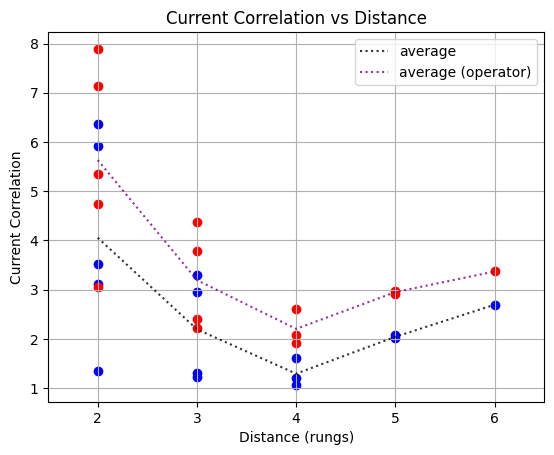

In [ ]:
current_correlation_by_distance_operator = {}


for correlation_pair in correlation_pairs:

    current_correlation_value = current_correlations_from_operator_normalized[correlation_pair]

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    if not distance in current_correlation_by_distance_operator:
        current_correlation_by_distance_operator[distance] = []
    
    current_correlation_by_distance_operator[distance].append(current_correlation_value)


distances = []
current_correlation_averages = []
current_correlation_averages_operator = []

for distance in current_correlation_by_distance_operator:
    distances.append(distance)
    current_correlation_averages.append(np.mean(current_correlation_by_distance[distance]))
    current_correlation_averages_operator.append(np.mean(current_correlation_by_distance_operator[distance]))


current_correlation_total_operator = sum(current_correlation_averages_operator)
print(f'current correlation total operator: {current_correlation_total_operator}')

# plot
for distance in current_correlation_by_distance:
    plt.scatter([distance]*len(current_correlation_by_distance[distance]), current_correlation_by_distance[distance], color='b')
    plt.scatter([distance]*len(current_correlation_by_distance_operator[distance]), current_correlation_by_distance_operator[distance], color='r')

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')
plt.plot(distances, current_correlation_averages_operator, linestyle=':', color='purple', alpha=0.8, label='average (operator)')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])

plt.legend()


plt.ylabel('Current Correlation')

plt.legend()

plt.grid()

plt.xlim(1.5, 6.5)
# plt.ylim(0, 0.5)
# plt.ylim(-0.2, 0.2)

plt.title('Current Correlation vs Distance')



plt.show()

In [ ]:
# data_dictionary = {}

# for correlation_pair in correlation_pairs:

#     data_dictionary[correlation_pair] = {}


#     data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

# data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
# data_dictionary['current_correlation_total'] = current_correlation_total_operator

In [ ]:
# we need to create the full data dictionary because it doesn't update nested items


data_dictionary = {}

for correlation_pair in correlation_pairs:

    data_dictionary[correlation_pair] = {}


    data_dictionary[correlation_pair]['beamsplitter_time'] = correlation_pair_to_beamsplitter_time[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_BS'] = correlation_pair_to_current_correlation[correlation_pair]
    data_dictionary[correlation_pair]['current_correlation_BS_value'] = correlation_pair_to_current_correlation_value[correlation_pair]

    data_dictionary[correlation_pair]['current_correlation_value'] = current_correlations_from_operator_normalized[correlation_pair]

data_dictionary['distances'] = distances

data_dictionary['current_correlation_BS_averages'] = current_correlation_averages
data_dictionary['distance_to_current_correlation_value_BS'] = current_correlation_by_distance
data_dictionary['current_correlation_BS_total'] = current_correlation_total

data_dictionary['current_correlation_averages'] = current_correlation_averages_operator
data_dictionary['distance_to_current_correlation_value'] = current_correlation_by_distance_operator
data_dictionary['current_correlation_total'] = current_correlation_total_operator


data_dictionary['times'] = times


In [ ]:
data_filename = 'current_correlations_data.h5'

keys = ('simulation', eigenstate, str(dephasing), coupling_point)

update_data_file(data_filename, data_dictionary, keys=keys, save_backup=True)


In [ ]:
# data_dict_from_file = load_nested_dict_from_hdf5(data_filename)

# print(data_dict_from_file.keys())
# print(data_dict_from_file['simulation'].keys())
# print(data_dict_from_file['simulation']['highest'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing']['coupling_point_2'].keys())
# print(data_dict_from_file['simulation']['highest']['no_dephasing']['coupling_point_2']['((1, 2), (3, 4))'].keys())

# print()
# print(data_dictionary.keys())
# print(data_dictionary['((1, 2), (3, 4))'].keys())


dict_keys(['data', 'simulation'])
dict_keys(['coupling_point_2', 'highest'])
dict_keys(['no_dephasing'])
dict_keys(['beamsplitter_measurement', 'coupling_point_2', 'operator_measurement'])
dict_keys(['((1, 2), (3, 4))', '((1, 2), (4, 5))', '((1, 2), (5, 6))', '((1, 2), (6, 7))', '((1, 2), (7, 8))', '((2, 3), (4, 5))', '((2, 3), (5, 6))', '((2, 3), (6, 7))', '((2, 3), (7, 8))', '((3, 4), (5, 6))', '((3, 4), (6, 7))', '((3, 4), (7, 8))', '((4, 5), (6, 7))', '((4, 5), (7, 8))', '((5, 6), (7, 8))', 'current_correlation_BS_averages', 'current_correlation_averages', 'distances', 'current_correlation_BS_total', 'current_correlation_total'])
dict_keys(['current_correlation_BS', 'beamsplitter_time', 'current_correlation_BS_value', 'current_correlation_value'])

dict_keys(['((1, 2), (3, 4))', '((1, 2), (4, 5))', '((1, 2), (5, 6))', '((1, 2), (6, 7))', '((1, 2), (7, 8))', '((2, 3), (4, 5))', '((2, 3), (5, 6))', '((2, 3), (6, 7))', '((2, 3), (7, 8))', '((3, 4), (5, 6))', '((3, 4), (6, 7))', '((3, 

# 3. Testing

In [ ]:
# analyze psi0 state occupcations


rho_reduced_truncated = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  (1,2) + (3,4), 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)



In [ ]:
basis_reduced = list(product(range(num_levels), repeat=4))
basis_reduced_truncated = [state for state in basis_reduced if sum(state) <= 4]


# two_particle_space_sum = 0
# for i in range(len(basis_reduced_truncated)):
#     state = basis_reduced_truncated[i]
#     if not sum(state) <= 2:
#         continue
#     print(f'{state}\t\t{np.round(rho_reduced_truncated[i,i].real,3)}')

#     if sum(state) == 2:
#         two_particle_space_sum += rho_reduced_truncated[i,i].real

# print(f'population in 2-particle subspace: {two_particle_space_sum}')


rho_populations = [rho_reduced_truncated[i,i].real for i in range(len(basis_reduced_truncated))]

sorted_indices = np.argsort(rho_populations)

rho_populations_sorted = np.array(rho_populations)[sorted_indices][::-1]
basis_reduced_truncated_sorted = np.array(basis_reduced_truncated)[sorted_indices][::-1]

for i in range(len(basis_reduced_truncated)):
    state = basis_reduced_truncated_sorted[i]
    pop = rho_populations_sorted[i]
    print(f'{state}\t{np.round(pop,3)}')


[0 0 1 1]	0.14
[0 1 1 0]	0.124
[1 1 0 0]	0.121
[1 0 0 1]	0.109
[0 1 1 1]	0.098
[1 1 0 1]	0.095
[0 0 1 0]	0.087
[1 0 0 0]	0.065
[0 1 0 0]	0.026
[1 0 1 1]	0.024
[0 0 0 1]	0.021
[1 1 1 0]	0.021
[0 1 0 1]	0.018
[1 1 1 1]	0.015
[1 0 1 0]	0.014
[0 0 0 0]	0.012
[0 0 1 2]	0.002
[0 0 2 1]	0.002
[1 2 0 0]	0.001
[1 0 0 2]	0.001
[0 2 1 0]	0.001
[0 1 2 0]	0.001
[0 0 2 0]	0.001
[0 1 2 1]	0.001
[1 0 1 2]	0.0
[0 2 0 0]	0.0
[2 1 0 0]	0.0
[1 2 1 0]	0.0
[2 1 0 1]	0.0
[0 0 0 2]	0.0
[2 0 0 1]	0.0
[0 1 1 2]	0.0
[0 1 0 2]	0.0
[2 0 0 0]	0.0
[1 2 0 1]	0.0
[1 1 0 2]	0.0
[1 0 2 1]	0.0
[1 0 2 0]	0.0
[1 1 2 0]	0.0
[0 0 2 2]	0.0
[0 2 0 1]	0.0
[0 2 2 0]	0.0
[2 0 1 0]	0.0
[2 0 0 2]	0.0
[2 1 1 0]	0.0
[2 2 0 0]	0.0
[0 0 0 3]	0.0
[0 0 3 0]	0.0
[0 0 3 1]	0.0
[0 0 1 3]	0.0
[0 2 1 1]	0.0
[0 1 3 0]	0.0
[1 3 0 0]	0.0
[1 0 0 3]	0.0
[0 1 0 3]	0.0
[3 0 0 0]	0.0
[2 0 1 1]	0.0
[0 3 0 0]	0.0
[1 0 3 0]	0.0
[0 2 0 2]	0.0
[0 3 0 1]	0.0
[3 1 0 0]	0.0
[3 0 0 1]	0.0
[0 3 1 0]	0.0
[3 0 1 0]	0.0
[0 0 4 0]	0.0
[0 0 0 4]	0.0
[0 4 0 0]	0.0
[

In [ ]:
rho_reduced_truncated

import pickle

# Save the ndarray to a pickle file
with open('rho_reduced_truncated.pkl', 'wb') as f:
    pickle.dump(rho_reduced_truncated, f)

# with open('rho_reduced_truncated.pkl', 'rb') as f:
#     rho_reduced_truncated = pickle.load(f)

In [ ]:
### reduce psi0 state qubits to 2 qubits instead of 4


rho_reduced_truncated_2Q = convert_particle_sector_to_reduced_density_matrix(psi0_state, 
                                                  basis_4Q, 
                                                  (1,2), 
                                                  num_qubits=num_qubits,
                                                  num_levels=num_levels)

In [ ]:
print(rho_reduced_truncated_2Q.dims)

[[15], [15]]


In [ ]:
reduced_basis_2Q = list(product(range(num_levels), repeat=2))
reduced_basis_2Q_truncated = [state for state in reduced_basis_2Q if sum(state) <= 4]

print(len(reduced_basis_2Q_truncated))

15


In [ ]:


rho_populations = [rho_reduced_truncated_2Q[i,i].real for i in range(len(reduced_basis_2Q_truncated))]

sorted_indices = np.argsort(rho_populations)

rho_populations_sorted = np.array(rho_populations)[sorted_indices][::-1]
basis_reduced_truncated_sorted = np.array(reduced_basis_2Q_truncated)[sorted_indices][::-1]

for i in range(len(basis_reduced_truncated_sorted)):
    state = basis_reduced_truncated_sorted[i]
    pop = rho_populations_sorted[i]
    print(f'{state}\t{np.round(pop,3)}')

[0 1]	0.268
[0 0]	0.264
[1 1]	0.252
[1 0]	0.213
[1 2]	0.002
[0 2]	0.002
[2 1]	0.0
[2 0]	0.0
[2 2]	0.0
[1 3]	0.0
[3 0]	0.0
[0 3]	0.0
[3 1]	0.0
[0 4]	0.0
[4 0]	0.0


In [ ]:
### let's analyze the expectation values of <a_i^\dagger a_j> on the eigenstate

psi0_state

len(psi0_fock.state)
psi0_fock.basis

### look at first placquette with qubits 1,2,3

# define coherence_ij = <a_i^\dagger a_j> for i,j in (1,2), (2,3), (3,1)

# 12
new_state = psi0_fock.apply_raising_operator(0, num_levels).apply_lowering_operator(1)
coherence_12 = psi0_fock.inner_product(new_state)

# 23
new_state = psi0_fock.apply_raising_operator(1, num_levels).apply_lowering_operator(2)
coherence_23 = psi0_fock.inner_product(new_state)

# 31
new_state = psi0_fock.apply_raising_operator(2, num_levels).apply_lowering_operator(0)
coherence_31 = psi0_fock.inner_product(new_state)

# print(f'J: {J}')
# print(f'J_parallel: {J_parallel}')

print(f'<a_1^\\dagger a_2>: {coherence_12}')
print(f'<a_2^\\dagger a_3>: {coherence_23}')
print(f'<a_3^\\dagger a_1>: {coherence_31}')

# calculate complex arguments
arg_12 = np.angle(coherence_12)
arg_23 = np.angle(coherence_23)
arg_31 = np.angle(coherence_31)

print(f'arg_12: {arg_12}')
print(f'arg_23: {arg_23}')
print(f'arg_31: {arg_31}')


print()
# 18
new_state = psi0_fock.apply_raising_operator(0, num_levels).apply_lowering_operator(7)
coherence_18 = psi0_fock.inner_product(new_state)
print(f'<a_1^\\dagger a_8>: {coherence_18}')


<a_1^\dagger a_2>: (-0.43013985041628167+0j)
<a_2^\dagger a_3>: (0.12568052029468538+0j)
<a_3^\dagger a_1>: (-0.20796704348369938+0j)
arg_12: 3.141592653589793
arg_23: 0.0
arg_31: 3.141592653589793

<a_1^\dagger a_8>: (0.06270790579232399+0j)
